# 🚨 Détection d'anomalies et score d'alerte stock

**Objectif** : construire un score d'alerte quotidien par référence, capable de
signaler automatiquement les situations à risque — avant qu'une rupture ou une
perte DLC ne survienne.

> 💡 **Pourquoi un score d'alerte ?** Les notebooks précédents ont montré qu'on
> peut prévoir la demande. Mais la prévision seule ne suffit pas : il faut aussi
> croiser cette prévision avec le stock actuel et la DLC restante pour savoir si
> une action est nécessaire aujourd'hui. Le score d'alerte transforme ces trois
> informations en un signal simple (🟢 Normal / 🟡 Vigilance / 🔴 Critique)
> lisible par n'importe quel opérateur logistique, sans avoir à interpréter un
> graphique de prévision.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'


## 1. Chargement des données

In [2]:
df = pd.read_csv('../data/stock_ventes_simules.csv', parse_dates=['date'])
produits = pd.read_csv('../data/referentiel_produits.csv')

print(f"SKUs disponibles : {sorted(df['sku'].unique())}")
df.head()


SKUs disponibles : ['DES-001', 'DES-002', 'DES-003', 'FRF-001', 'FRF-002', 'YAB-001', 'YAB-002', 'YAB-003']


,date,sku,produit,famille,dlc_jours,demande,production,stock_fin_journee,stock_securite,perte_dlc,rupture
0,2025-01-01,YAB-001,Yaourt à boire nature 1L,Yaourt à boire,18,352,385,2314,612,162,False
1,2025-01-02,YAB-001,Yaourt à boire nature 1L,Yaourt à boire,18,1968,2138,2387,612,97,False
2,2025-01-03,YAB-001,Yaourt à boire nature 1L,Yaourt à boire,18,594,581,2286,612,88,False
3,2025-01-04,YAB-001,Yaourt à boire nature 1L,Yaourt à boire,18,306,309,2197,612,92,False
4,2025-01-05,YAB-001,Yaourt à boire nature 1L,Yaourt à boire,18,2468,2355,2084,612,0,False


## 2. Prévision de la demande sur toutes les références

Pour calculer un score d'alerte sur chaque référence, on a besoin d'une
prévision de demande pour les 7 prochains jours. On applique Prophet à chaque
SKU et on stocke les résultats.

> 💡 **Horizon 7 jours** : on raccourcit ici l'horizon de 14 à 7 jours pour le
> score d'alerte opérationnel. 7 jours correspond au cycle de réapprovisionnement
> hebdomadaire typique d'un site industriel — c'est l'horizon minimal pour
> déclencher une action corrective à temps.

In [3]:
HORIZON_ALERTE = 7

previsions = []

for sku in df['sku'].unique():
    df_sku = df[df['sku'] == sku][['date', 'demande']].copy().sort_values('date')
    dlc = produits[produits['sku'] == sku]['dlc_jours'].values[0]
    produit = produits[produits['sku'] == sku]['nom'].values[0]

    # Entraînement Prophet sur toute la série sauf les 7 derniers jours
    date_max = df_sku['date'].max()
    train = df_sku[df_sku['date'] <= date_max - pd.Timedelta(days=HORIZON_ALERTE)].copy()
    train_p = train.rename(columns={'date': 'ds', 'demande': 'y'})

    m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                daily_seasonality=False, seasonality_mode='multiplicative',
                interval_width=0.80)
    m.fit(train_p)

    future = m.make_future_dataframe(periods=HORIZON_ALERTE)
    fc = m.predict(future)
    fc_horizon = fc[fc['ds'] > date_max - pd.Timedelta(days=HORIZON_ALERTE)][['ds','yhat','yhat_lower','yhat_upper']].copy()
    fc_horizon['yhat'] = fc_horizon['yhat'].clip(lower=0)
    fc_horizon['sku'] = sku
    fc_horizon['produit'] = produit
    fc_horizon['dlc_jours'] = dlc

    # Stock réel du dernier jour connu (chargé depuis df complet)
    df_sku_complet = df[df['sku'] == sku].sort_values('date')
    stock_actuel = df_sku_complet[df_sku_complet['date'] == date_max]['stock_fin_journee'].values
    fc_horizon['stock_actuel'] = stock_actuel[0] if len(stock_actuel) > 0 else 0

    previsions.append(fc_horizon)

df_prev = pd.concat(previsions, ignore_index=True)
print(f"Prévisions générées : {len(df_prev)} lignes ({df_prev['sku'].nunique()} SKUs x {HORIZON_ALERTE} jours)")
df_prev.head(10)


10:31:51 - cmdstanpy - INFO - Chain [1] start processing


10:31:51 - cmdstanpy - INFO - Chain [1] done processing


10:31:51 - cmdstanpy - INFO - Chain [1] start processing


10:31:52 - cmdstanpy - INFO - Chain [1] done processing


10:31:52 - cmdstanpy - INFO - Chain [1] start processing


...

10:31:52 - cmdstanpy - INFO - Chain [1] done processing


10:31:52 - cmdstanpy - INFO - Chain [1] start processing


10:31:52 - cmdstanpy - INFO - Chain [1] done processing


Prévisions générées : 56 lignes (8 SKUs x 7 jours)


,ds,yhat,yhat_lower,yhat_upper,sku,produit,dlc_jours,stock_actuel
0,2025-12-24,1203.753698,485.916876,1911.274620,YAB-001,Yaourt à boire nature 1L,18,2107
1,2025-12-25,1416.951593,673.269524,2181.157687,YAB-001,Yaourt à boire nature 1L,18,2107
2,2025-12-26,1407.559375,692.903459,2147.393853,YAB-001,Yaourt à boire nature 1L,18,2107
3,2025-12-27,1097.665985,301.756012,1834.859942,YAB-001,Yaourt à boire nature 1L,18,2107
4,2025-12-28,1315.781571,597.751420,2097.125616,YAB-001,Yaourt à boire nature 1L,18,2107
5,2025-12-29,1572.844142,876.777391,2323.688365,YAB-001,Yaourt à boire nature 1L,18,2107
6,2025-12-30,1475.824614,724.535247,2239.363158,YAB-001,Yaourt à boire nature 1L,18,2107
7,2025-12-24,781.725678,497.190878,1060.192945,YAB-002,Yaourt à boire fraise 1L,18,1415
8,2025-12-25,848.508723,590.657701,1141.584534,YAB-002,Yaourt à boire fraise 1L,18,1415
9,2025-12-26,828.442386,553.820772,1133.353910,YAB-002,Yaourt à boire fraise 1L,18,1415


## 3. Construction du score d'alerte

> 💡 **Comment fonctionne le score ?** On calcule trois indicateurs pour chaque
> référence sur les 7 prochains jours, puis on les combine en un score composite :
>
> **Indicateur 1 — Risque de rupture** : si la demande prévue sur 7 jours dépasse
> le stock actuel, la référence va tomber en rupture. On mesure l'écart en
> nombre de jours avant rupture théorique.
>
> **Indicateur 2 — Risque de perte DLC** : si la couverture de stock actuelle
> (stock ÷ demande moyenne prévue) dépasse la DLC du produit, une partie du
> stock ne sera pas vendue avant péremption.
>
> **Indicateur 3 — Volatilité de la prévision** : si l'intervalle de confiance
> est très large, la prévision est incertaine — on augmente prudemment le score
> pour tenir compte du risque d'erreur.
>
> Le score final est normalisé entre 0 (aucun risque) et 100 (risque maximal),
> puis converti en niveau d'alerte : 🟢 Normal / 🟡 Vigilance / 🔴 Critique.

In [4]:
resultats = []

for sku, groupe in df_prev.groupby('sku'):
    produit = groupe['produit'].iloc[0]
    dlc = groupe['dlc_jours'].iloc[0]
    stock = groupe['stock_actuel'].iloc[0]

    demande_prev_7j = groupe['yhat'].sum()
    demande_moy_jour = groupe['yhat'].mean()
    incertitude = (groupe['yhat_upper'] - groupe['yhat_lower']).mean()

    if demande_moy_jour > 0:
        jours_avant_rupture = stock / demande_moy_jour
    else:
        jours_avant_rupture = 99

    score_rupture   = max(0, min(100, (1 - jours_avant_rupture / HORIZON_ALERTE) * 100))
    couverture      = jours_avant_rupture
    score_dlc       = max(0, min(100, (couverture - dlc) / dlc * 100)) if couverture > dlc else 0
    score_volatilite = min(100, (incertitude / max(demande_moy_jour, 1)) * 50)
    score_final     = round(0.50 * score_rupture + 0.35 * score_dlc + 0.15 * score_volatilite, 1)

    if score_final >= 60:   niveau, emoji = 'CRITIQUE',  '🔴'
    elif score_final >= 30: niveau, emoji = 'VIGILANCE', '🟡'
    else:                   niveau, emoji = 'NORMAL',    '🟢'

    resultats.append({'sku': sku, 'produit': produit, 'dlc_jours': dlc,
                      'stock_actuel': round(stock), 'demande_prev_7j': round(demande_prev_7j),
                      'jours_avant_rupture': round(jours_avant_rupture, 1),
                      'couverture_jours': round(couverture, 1),
                      'score_rupture': round(score_rupture, 1),
                      'score_dlc': round(score_dlc, 1),
                      'score_volatilite': round(score_volatilite, 1),
                      'score_final': score_final, 'niveau_alerte': niveau, 'emoji': emoji})

df_alertes = pd.DataFrame(resultats).sort_values('score_final', ascending=False).reset_index(drop=True)
print(df_alertes[['sku','produit','stock_actuel','demande_prev_7j','jours_avant_rupture','score_final','niveau_alerte']].to_string(index=False))

    sku                          produit  stock_actuel  demande_prev_7j  jours_avant_rupture  score_final niveau_alerte
DES-001    Crème dessert vanille pack x4           282             2951                  0.7         55.6     VIGILANCE
DES-003             Flan caramel pack x4           205             2716                  0.5         54.7     VIGILANCE
DES-002   Crème dessert chocolat pack x4           657             3719                  1.2         52.6     VIGILANCE
FRF-002 Fromage frais ail & fines herbes           242             3106                  0.5         50.3     VIGILANCE
FRF-001        Fromage frais nature 500g           517             4521                  0.8         49.1     VIGILANCE
YAB-001         Yaourt à boire nature 1L          2107             9490                  1.6         47.1     VIGILANCE
YAB-002         Yaourt à boire fraise 1L          1415             5553                  1.8         42.6     VIGILANCE
YAB-003          Yaourt à boire pêche 1L

## 4. Tableau de bord des alertes

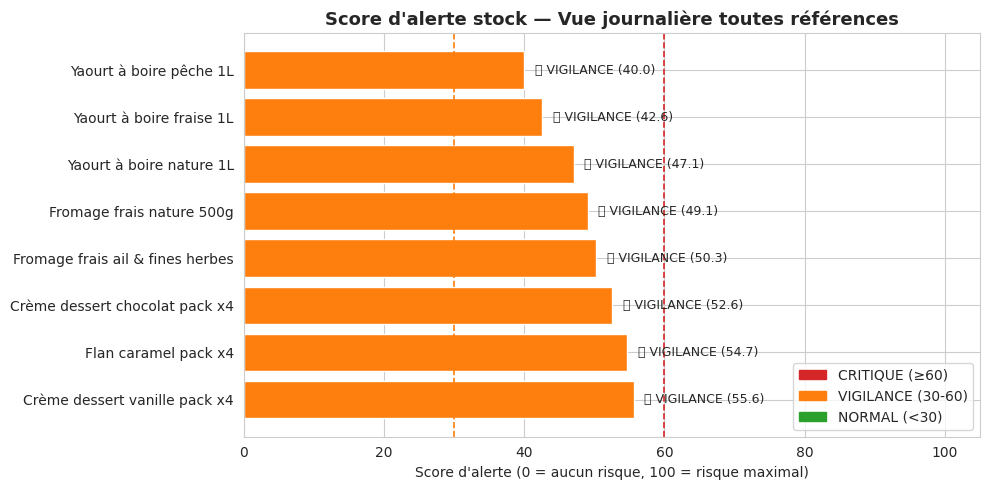

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

couleurs = {'CRITIQUE': '#d62728', 'VIGILANCE': '#ff7f0e', 'NORMAL': '#2ca02c'}
barres = ax.barh(
    df_alertes['produit'],
    df_alertes['score_final'],
    color=[couleurs[n] for n in df_alertes['niveau_alerte']]
)

ax.axvline(30, color='#ff7f0e', linestyle='--', linewidth=1.2, label='Seuil Vigilance (30)')
ax.axvline(60, color='#d62728', linestyle='--', linewidth=1.2, label='Seuil Critique (60)')
ax.set_xlim(0, 105)
ax.set_xlabel("Score d'alerte (0 = aucun risque, 100 = risque maximal)")
ax.set_title("Score d'alerte stock — Vue journalière toutes références")

for bar, (_, row) in zip(barres, df_alertes.iterrows()):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f"{row['emoji']} {row['niveau_alerte']} ({row['score_final']})",
            va='center', fontsize=9)

legend_patches = [
    mpatches.Patch(color='#d62728', label='CRITIQUE (≥60)'),
    mpatches.Patch(color='#ff7f0e', label='VIGILANCE (30-60)'),
    mpatches.Patch(color='#2ca02c', label='NORMAL (<30)')
]
ax.legend(handles=legend_patches, loc='lower right')
plt.tight_layout()
plt.show()


Ce graphique constitue la **vue principale du tableau de bord opérationnel** :
en un coup d'œil, le responsable logistique identifie quelles références
nécessitent une action immédiate (rouge), lesquelles méritent une surveillance
renforcée (orange), et lesquelles sont sous contrôle (vert).

## 5. Analyse détaillée des références critiques

In [6]:
critiques = df_alertes[df_alertes['niveau_alerte'].isin(['CRITIQUE', 'VIGILANCE'])].copy()

if len(critiques) == 0:
    print("Aucune référence en situation critique ou de vigilance.")
else:
    for _, row in critiques.iterrows():
        print(f"{row['emoji']} {row['produit']} ({row['sku']})")
        print(f"   Stock actuel        : {row['stock_actuel']:,} unités")
        print(f"   Demande prévue 7j   : {row['demande_prev_7j']:,} unités")
        print(f"   Jours avant rupture : {row['jours_avant_rupture']} jours")
        print(f"   Couverture vs DLC   : {row['couverture_jours']} jours / DLC {row['dlc_jours']} jours")
        print(f"   Score final         : {row['score_final']} / 100")
        print()


🟡 Crème dessert vanille pack x4 (DES-001)
   Stock actuel        : 282 unités
   Demande prévue 7j   : 2,951 unités
   Jours avant rupture : 0.7 jours
   Couverture vs DLC   : 0.7 jours / DLC 14 jours
   Score final         : 55.6 / 100

🟡 Flan caramel pack x4 (DES-003)
   Stock actuel        : 205 unités
   Demande prévue 7j   : 2,716 unités
   Jours avant rupture : 0.5 jours
   Couverture vs DLC   : 0.5 jours / DLC 12 jours
   Score final         : 54.7 / 100

🟡 Crème dessert chocolat pack x4 (DES-002)
   Stock actuel        : 657 unités
   Demande prévue 7j   : 3,719 unités
   Jours avant rupture : 1.2 jours
   Couverture vs DLC   : 1.2 jours / DLC 14 jours
   Score final         : 52.6 / 100

🟡 Fromage frais ail & fines herbes (FRF-002)
   Stock actuel        : 242 unités
   Demande prévue 7j   : 3,106 unités
   Jours avant rupture : 0.5 jours
   Couverture vs DLC   : 0.5 jours / DLC 21 jours
   Score final         : 50.3 / 100

🟡 Fromage frais nature 500g (FRF-001)
   Stock actuel

## 6. Évolution du score dans le temps (simulation)

Pour donner une idée de ce que serait le suivi quotidien du score d'alerte,
on recalcule le score sur les 30 derniers jours pour la référence la plus critique.

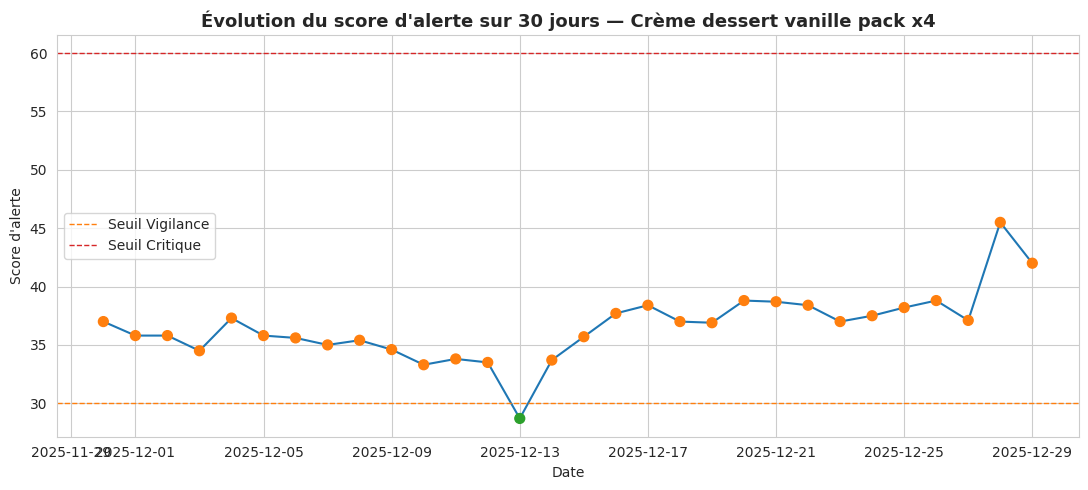

In [7]:
sku_critique = df_alertes.iloc[0]['sku']
produit_critique = df_alertes.iloc[0]['produit']
dlc_critique = df_alertes.iloc[0]['dlc_jours']

df_sku = df[df['sku'] == sku_critique].sort_values('date').copy()
date_max = df_sku['date'].max()
fenetre = 30

scores_historiques = []

for j in range(fenetre, 0, -1):
    date_ref = date_max - pd.Timedelta(days=j)
    stock_j = df_sku[df_sku['date'] == date_ref]['stock_fin_journee'].values
    demande_prev_j = df_sku[
        (df_sku['date'] > date_ref) & 
        (df_sku['date'] <= date_ref + pd.Timedelta(days=7))
    ]['demande'].mean()

    if len(stock_j) == 0 or demande_prev_j == 0:
        continue

    stock_val = stock_j[0]
    jours_rupture = stock_val / demande_prev_j
    couverture = jours_rupture

    score_r = max(0, min(100, (1 - jours_rupture / 7) * 100))
    score_d = max(0, min(100, (couverture - dlc_critique) / dlc_critique * 100)) if couverture > dlc_critique else 0
    score = round(0.50 * score_r + 0.35 * score_d, 1)

    if score >= 60: niveau = 'CRITIQUE'
    elif score >= 30: niveau = 'VIGILANCE'
    else: niveau = 'NORMAL'

    scores_historiques.append({'date': date_ref, 'score': score, 'niveau': niveau})

df_hist = pd.DataFrame(scores_historiques)

couleurs_pts = {'CRITIQUE': '#d62728', 'VIGILANCE': '#ff7f0e', 'NORMAL': '#2ca02c'}

fig, ax = plt.subplots()
ax.plot(df_hist['date'], df_hist['score'], color='#1f77b4', linewidth=1.5, zorder=1)
ax.scatter(df_hist['date'], df_hist['score'],
           c=[couleurs_pts[n] for n in df_hist['niveau']], s=50, zorder=2)
ax.axhline(30, color='#ff7f0e', linestyle='--', linewidth=1, label='Seuil Vigilance')
ax.axhline(60, color='#d62728', linestyle='--', linewidth=1, label='Seuil Critique')
ax.set_title(f"Évolution du score d'alerte sur 30 jours — {produit_critique}")
ax.set_ylabel("Score d'alerte")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.show()


Ce type de graphique permet de suivre si une référence est en train de
**dériver progressivement vers le rouge** avant même d'atteindre le seuil
critique — un signal précoce bien plus utile qu'une alarme déclenchée au
dernier moment.

## 7. Synthèse et intégration dans le workflow opérationnel

**Ce que produit ce notebook au quotidien :**

| Sortie | Usage |
|--------|-------|
| Tableau des scores par SKU | Priorisation des actions du matin par l'équipe logistique |
| Graphique d'alerte coloré | Affichage sur écran de supervision ou envoi par email |
| Évolution temporelle | Détection précoce des dérives avant rupture |

**Workflow opérationnel proposé :**

1. Chaque matin, le script est exécuté automatiquement sur les données de la veille
2. Les références en 🔴 **CRITIQUE** déclenchent une action immédiate (commande d'urgence ou destruction stock périmé)
3. Les références en 🟡 **VIGILANCE** sont examinées lors de la réunion de planification journalière
4. Les références en 🟢 **NORMAL** ne nécessitent aucune action

**Prochaine étape** : intégration de ces alertes dans un **dashboard interactif**
(`dashboard/app.py`) permettant à l'équipe de consulter et filtrer les alertes
en temps réel, sans avoir à exécuter le notebook manuellement.